In [ ]:
install.packages(c("googledrive","sqldf"))
library(sqldf)
library(googledrive)
drive_auth()

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite

Is it OK to cache OAuth access credentials in the folder ~/.cache/gargle
between R sessions?
1: Yes
2: No


Selection: 1


Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=4df32531a923339d74d73a94ec62a653&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQWVvV3VNX01lNm9NM1dJaUo0bW4wdHNuX1NSb1BTTTdvNVlMWnh0eENKV213Wk9YMkVBTURqRWdCRE83RTRvM2doUHhxdyIsInN0YXRlIjoiNGRmMzI1MzFhOTIzMzM5ZDc0ZDczYTk0ZWM2MmE2NTMifQ==


In [ ]:
# downloading all the datasets fro northstar from the drive
drive_download("deliveries.csv",path="deliveries.csv",overwrite=TRUE)
drive_download("orders.csv",path="orders.csv",overwrite=TRUE)
drive_download("app_events.csv",path="app_events.csv",overwrite=TRUE)
drive_download("complaints.csv",path="complaints.csv",overwrite=TRUE)
drive_download("customers.csv",path="customers.csv",overwrite=TRUE)
drive_download("hubs.csv",path="hubs.csv",overwrite=TRUE)
drive_download("drivers.csv",path="drivers.csv",overwrite=TRUE)
drive_download("incidents.csv",path="incidents.csv",overwrite=TRUE)
drive_download("vehicles.csv",path="vehicles.csv",overwrite=TRUE)

File downloaded:

• deliveries.csv <id: 1MgMqoz1WaTWdyMUqEX4X9_sMWodBRzhY>

Saved locally as:

• deliveries.csv

File downloaded:

• orders.csv <id: 1XMMD9wF4-157x4-puoOrMVf_os2it58N>

Saved locally as:

• orders.csv

File downloaded:

• app_events.csv <id: 13Eac7Kp9FO5kzHj_qVgFyJCXCLt8nG80>

Saved locally as:

• app_events.csv

File downloaded:

• complaints.csv <id: 1Q0fjkbkzB2hPZwK-tbZa3dCLQ_4FXiG7>

Saved locally as:

• complaints.csv

File downloaded:

• customers.csv <id: 1XIwfY0FuzKnHT8ArN2v7UoFJ9tZu3_AZ>

Saved locally as:

• customers.csv

File downloaded:

• hubs.csv <id: 1ftsuxbeSKwYcT8qZItd63sxZQXtKWSLB>

Saved locally as:

• hubs.csv

File downloaded:

• drivers.csv <id: 1Teax1f31AK6MHIfWOJVztVruVy-1wRGM>

Saved locally as:

• drivers.csv

File downloaded:

• incidents.csv <id: 1w26BhACKycPP5GSwrf-TmduCFGX1P_cV>

Saved locally as:

• incidents.csv

File downloaded:

• vehicles.csv <id: 1dj32Zk-JKa8JJfypQo-VaWfGwYcBr_2K>

Saved locally as:

• vehicles.csv



In [ ]:
# import data from files to R dataframe
deliveries <- read.csv("deliveries.csv")
orders <- read.csv("orders.csv")
complaints <- read.csv("complaints.csv")
app_events <- read.csv("app_events.csv")
customers <- read.csv("customers.csv")
hubs <- read.csv("hubs.csv")
drivers <- read.csv("drivers.csv")
incidents <- read.csv("incidents.csv")
vehicles <- read.csv("vehicles.csv")

In [ ]:
# List of all dataframes we loaded
tables <- list("deliveries" = deliveries, "orders" = orders, "complaints" = complaints,
               "app_events" = app_events, "customers" = customers, "hubs" = hubs,
               "drivers" = drivers, "incidents" = incidents, "vehicles" = vehicles)

# Looping through each table and printing inspection details
# Print the table name of each table followed by its details
for (name in names(tables)) {
  cat(paste0("\n==============================\n", "Table: ", name, "\n==============================\n"))

  print("--- First 5 Rows ---")
  print(head(tables[[name]], 5))

  print("--- Structure ---")
  print(str(tables[[name]]))

  print("--- Summary ---")
  print(summary(tables[[name]]))
}


Table: deliveries
[1] "--- First 5 Rows ---"
  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time
1     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00
2     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00
3     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00
4     DL00004   O00313      D116       V055    H02 2024-03-08 23:31:00
5     DL00005   O00844      D108       V034    H01 2025-09-21 11:43:00
       delivery_completed_at delivery_status route_distance_km
1 2024-06-19 09:05:59.904311          Failed             17.26
2 2025-01-11 17:39:00.000000          OnTime             10.34
3 2025-06-02 21:45:32.366770          OnTime              7.92
4 2024-03-09 23:30:08.103702         Delayed             16.42
5 2025-09-21 15:45:34.131056          OnTime             14.52
  manual_route_override_count proof_of_completion_missing
1                           1                           0
2                           1     

# Data Cleaning
Based on the inspection, the following processes are done:
1. **Standardize Zones**: Zones converted to lowercase and change 'ctr' to 'control'.
2. **Convert Dates**: Transform date columns (character strings) into proper R Date objects.
3. **Convert Categorical Data**: Change columns like status and vehicle type into 'Factors'.
4. **Handle Missing Values**: Address NAs in battery health and delivery data.

In [ ]:
# Checking all tables for columns containing 'zone'
for (name in names(tables)) {
  cols <- colnames(tables[[name]])
  zone_cols <- cols[grepl("zone", cols, ignore.case = TRUE)]
  if (length(zone_cols) > 0) {
    cat(paste0("Table: ", name, " contains zone columns: ", paste(zone_cols, collapse = ", "), "\n"))
  }
}

Table: orders contains zone columns: pickup_zone, dropoff_zone
Table: app_events contains zone columns: zone_context
Table: customers contains zone columns: home_zone
Table: hubs contains zone columns: zone
Table: drivers contains zone columns: base_zone
Table: vehicles contains zone columns: assigned_zone


In [ ]:
library(lubridate)

# 1. Standardize all identified zone and control columns
clean_zone <- function(x) {
  x <- tolower(as.character(x))
  x[x == "ctr"] <- "control"
  return(as.factor(x))
}

# Apply cleaning to all discovered zone columns
if ("assigned_zone" %in% colnames(vehicles)) vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)
if ("zone" %in% colnames(hubs)) hubs$zone <- clean_zone(hubs$zone)
if ("pickup_zone" %in% colnames(orders)) orders$pickup_zone <- clean_zone(orders$pickup_zone)
if ("dropoff_zone" %in% colnames(orders)) orders$dropoff_zone <- clean_zone(orders$dropoff_zone)
if ("zone_context" %in% colnames(app_events)) app_events$zone_context <- clean_zone(app_events$zone_context)
if ("home_zone" %in% colnames(customers)) customers$home_zone <- clean_zone(customers$home_zone)
if ("base_zone" %in% colnames(drivers)) drivers$base_zone <- clean_zone(drivers$base_zone)

# 2. Converting all date columns using lubridate for robust parsing
# Helper to check if a column name suggests a date/time
is_date_col <- function(col_name) {
  grepl("date|time|at|timestamp", col_name, ignore.case = TRUE)
}

# Loop through each table in our list
for (table_name in names(tables)) {
  df <- get(table_name)
  cols <- colnames(df)

  for (col in cols) {
    if (is_date_col(col)) {
      # Use parse_date_time for flexible parsing of various formats
      new_dates <- parse_date_time(as.character(df[[col]]), orders = c("ymd HMS", "ymd", "mdy HMS", "mdy"), quiet = TRUE)

      # Only update if we actually managed to parse something
      if (!all(is.na(new_dates))) {
        df[[col]] <- new_dates
        cat(paste0("Converted column '", col, "' in table '", table_name, "' to datetime\n"))
      }
    }
  }
  # Assign the modified dataframe back to the global environment
  assign(table_name, df, envir = .GlobalEnv)
}

# 3. Categorical Data Handling
# Automatically convert character columns with low cardinality to factors
for (table_name in names(tables)) {
  df <- get(table_name)
  char_cols <- sapply(df, is.character)
  for (col in names(df)[char_cols]) {
    # If the column has fewer than 20 unique values, it's likely categorical
    if (length(unique(df[[col]])) < 20) {
      df[[col]] <- as.factor(df[[col]])
      cat(paste0("Converted '", col, "' in '", table_name, "' to factor\n"))
    }
  }
  assign(table_name, df, envir = .GlobalEnv)
}

# 4. Missing Value Handling for numerical and categorical data
cat("Scanning for missing values (NAs)...\n")
for (table_name in names(tables)) {
  df <- get(table_name)
  na_counts <- colSums(is.na(df))
  cols_with_nas <- names(na_counts[na_counts > 0])

  if (length(cols_with_nas) > 0) {
    for (col in cols_with_nas) {
      if (is.numeric(df[[col]])) {
        # Fill numeric NAs with median
        fill_val <- median(df[[col]], na.rm = TRUE)
        df[[col]][is.na(df[[col]])] <- fill_val
        cat(paste0("Filled ", na_counts[col], " NAs in '", table_name, ".", col, "' with median: ", round(fill_val, 2), "\n"))
      } else if (is.factor(df[[col]])) {
        # Add 'Unknown' level for factors and fill NAs
        levels(df[[col]]) <- c(levels(df[[col]]), "Unknown")
        df[[col]][is.na(df[[col]])] <- "Unknown"
        cat(paste0("Labelled ", na_counts[col], " NAs in '", table_name, ".", col, "' as 'Unknown'\n"))
      }
    }
    assign(table_name, df, envir = .GlobalEnv)
  }
}

print("Comprehensive cleaning, parsing, and missing value handling complete.")


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




Converted column 'dispatch_time' in table 'deliveries' to datetime
Converted column 'delivery_completed_at' in table 'deliveries' to datetime
Converted column 'order_created_at' in table 'orders' to datetime
Converted column 'created_at' in table 'complaints' to datetime
Converted column 'event_timestamp' in table 'app_events' to datetime
Converted column 'signup_date' in table 'customers' to datetime
Converted column 'reported_at' in table 'incidents' to datetime
Converted column 'commission_date' in table 'vehicles' to datetime
Converted 'hub_id' in 'deliveries' to factor
Converted 'delivery_status' in 'deliveries' to factor
Converted 'service_type' in 'orders' to factor
Converted 'priority_level' in 'orders' to factor
Converted 'booking_channel' in 'orders' to factor
Converted 'complaint_type' in 'complaints' to factor
Converted 'channel' in 'complaints' to factor
Converted 'severity' in 'complaints' to factor
Converted 'status' in 'complaints' to factor
Converted 'event_type' in 'a

# Summary statistics

In [ ]:
library(dplyr)

# --- A. Basic Overviews ---
print("Deliveries Summary:")
print(summary(deliveries))

# Individual metrics
cat("\nAverage Route Distance:", mean(deliveries$route_distance_km, na.rm = TRUE), "\n")

# --- B. Counting Categorical values ---
cat("\n--- Counts by Delivery Status ---\n")
print(table(deliveries$delivery_status))

cat("\n--- Status by Hub ID ---\n")
print(table(deliveries$delivery_status, deliveries$hub_id))

# --- C. Grouped Summaries (aggregate) ---
cat("\n--- Avg Distance by Status (Base R) ---\n")
dist_by_status <- aggregate(route_distance_km ~ delivery_status, data = deliveries, FUN = mean)
print(dist_by_status)

# --- D. Advanced Summaries (dplyr) ---
cat("\n--- Detailed Stats by Status ---\n")
delivery_performance <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(
    avg_dist = mean(route_distance_km, na.rm = TRUE),
    total_count = n(),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE)
  )

print(delivery_performance)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Deliveries Summary:"
    delivery_id       order_id       driver_id       vehicle_id      hub_id   
 Length   :950   Length   :950   Length   :950   Length   :950   H01    :136  
 N.unique :950   N.unique :950   N.unique :170   N.unique :120   H08    :128  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0   H04    :127  
 Min.nchar:  7   Min.nchar:  6   Min.nchar:  4   Min.nchar:  4   H03    :119  
 Max.nchar:  7   Max.nchar:  6   Max.nchar:  4   Max.nchar:  4   H05    :115  
                                                                 H07    :115  
                                                                 (Other):210  
 dispatch_time                 delivery_completed_at         delivery_status
 Min.   :2024-01-01 03:20:00   Min.   :2024-01-01 15:35:48   Delayed:202    
 1st Qu.:2024-06-21 17:54:00   1st Qu.:2024-06-18 14:13:03   Failed :132    
 Median :2024-12-12 14:19:30   Median :2024-12-13 02:04:50   OnTime :616    
 Mean   :2024-12-20 13:10:27   Mea

### Business Interpretation of Summary Statistics
1. **Basic Overview**: Using `summary()` to give a statistical snapshot of all columns and `mean()` to find the specific average of the route distances.
2. **Category Counts**: The `table()` function counts how many deliveries fall into each status (OnTime, Delayed, etc.) and breaks them down further by Hub ID.
3. **Grouped Summaries**: Using the `aggregate()` function from R to calculate the average distance for each delivery status.
4. **Advanced Summaries**: Using the `dplyr` package to create a detailed performance table, calculating the average distance, total volume, and average customer rating simultaneously for each status group.

# Using SQL in R with `sqldf`

We can use the `sqldf` package to run SQL queries directly on our R dataframes.

In [ ]:
# 1. Filtering Rows
# Finding all deliveries where the route distance was greater than 20km
long_routes <- sqldf("SELECT * FROM deliveries WHERE route_distance_km > 20")
print("Deliveries with distance > 20km:")
print(head(long_routes))

[1] "Deliveries with distance > 20km:"
  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time
1     DL00007   O00097      D151       V037    H07 2024-01-09 13:41:00
2     DL00009   O00297      D088       V029    H05 2024-04-12 21:33:00
3     DL00015   O00394      D067       V056    H04 2024-08-16 22:47:00
4     DL00017   O01249      D002       V008    H05 2024-08-25 18:26:00
5     DL00020   O00054      D157       V065    H01 2025-03-29 12:59:00
6     DL00035   O00275      D015       V038    H07 2025-05-21 21:35:00
  delivery_completed_at delivery_status route_distance_km
1   2024-01-10 23:39:11         Delayed             32.72
2   2024-04-13 01:18:52          OnTime             40.23
3   2024-08-17 08:15:56          OnTime             26.58
4   2024-08-26 03:05:42         Delayed             20.79
5   2025-03-29 14:40:37          OnTime             24.31
6   2025-05-22 01:56:14          OnTime             22.05
  manual_route_override_count proof_of_completion_missing


In [ ]:
# 2. Joining Two Tables
# Joining complaints with deliveries using order_id to see driver details
complaint_drivers <- sqldf("
  SELECT c.complaint_id, d.driver_id, d.delivery_status
  FROM complaints c
  JOIN deliveries d ON c.order_id = d.order_id
")
print("Complaints joined with Driver IDs:")
print(head(complaint_drivers))

[1] "Complaints joined with Driver IDs:"
  complaint_id driver_id delivery_status
1       CP0001      D150          OnTime
2       CP0002      D170         Delayed
3       CP0003      D103         Delayed
4       CP0004      D160          OnTime
5       CP0005      D137         Delayed
6       CP0006      D049          OnTime


In [ ]:
# 3. Grouping and Aggregating
# Calculating the average route distance per hub
hub_stats <- sqldf("
  SELECT hub_id, AVG(route_distance_km) as avg_dist
  FROM deliveries
  GROUP BY hub_id
")
print("Average Distance per Hub:")
print(hub_stats)

[1] "Average Distance per Hub:"
  hub_id avg_dist
1    H01 13.64331
2    H02 14.16915
3    H03 14.51555
4    H04 13.38457
5    H05 14.32165
6    H06 14.41221
7    H07 14.28696
8    H08 12.81547


In [ ]:
# 4. Counting Records
# Counting how many 'Failed' deliveries occurred for each vehicle
vehicle_failures <- sqldf("
  SELECT vehicle_id, COUNT(*) as failure_count
  FROM deliveries
  WHERE delivery_status = 'Failed'
  GROUP BY vehicle_id
  ORDER BY failure_count DESC
")
print("Number of Failures per Vehicle:")
print(head(vehicle_failures))

[1] "Number of Failures per Vehicle:"
  vehicle_id failure_count
1       V109             5
2       V037             5
3       V017             5
4       V057             4
5       V002             4
6       V114             3


### Business Interpretation of SQL Query Outputs
- **Filtering (Long Routes)**: Delivery distances of over 20km are of high risk. For NorthStar, long routes are often the primary source of 'Failed' or 'Delayed' statuses due to higher traffic and fuel risks.
- **Joining (Complaints & Drivers)**: By linking these tables, we can see if specific drivers or vehicle types are recurring in customer complaints, indicating a need for targeted training or maintenance.
- **Aggregating (Avg Distance per Hub)**: This highlights which hubs need longer routes. A hub with high average distances but less staff is a likely root cause for delays.
- **Counting (Failures per Vehicle)**: Tracking failures by vehicle ID allows the maintenance team to identify which vehicles are less efficient and frequently breaking down to disrupt the logistics chain.

## SQL Optimization

#### Why Filter Early?
Filtering data as early as possible in the query (using `WHERE` clauses) improves performance because the database engine processes fewer rows. This reduces memory usage and speeds up calculations.

#### Which Columns to Index?
Indexing acts like a reference for your data. indexing should be frequently done on columns used in:
*   **Joins**: `hub_id`, `driver_id`
*   **Filtering**: `delivery_status`, `dispatch_time` (date)
*   **Sorting**: `route_distance_km`

In [ ]:
library(sqldf)

# Clear memory to prevent contradictions in database
options(sqldf.connection = NULL)

# 1. Timing comparison
# The slow way: Selecting everything (*)
cat("Timing: Slow Query (Selecting ALL columns)\n")
slow_time <- system.time({
  res1 <- sqldf("SELECT * FROM deliveries WHERE hub_id = 'H01'")
})
print(slow_time)

# The fast way: Selecting only 2 columns
cat("\nTiming: Fast Query (Selecting 2 specific columns)\n")
fast_time <- system.time({
  res2 <- sqldf("SELECT delivery_id, delivery_status FROM deliveries WHERE hub_id = 'H01'")
})
print(fast_time)

# 3. Adding an Index
# Creating an index for 'hub_id' so the computer doesn't have to scan every row.
cat("\nCreating an Index\n")
# We need a brief database connection to demonstrate EXPLAIN
con <- dbConnect(SQLite(), ":memory:")
dbWriteTable(con, "deliveries", deliveries)
dbExecute(con, "CREATE INDEX idx_hub ON deliveries(hub_id)")

# 4. Verification
# SEARCH strategy means it used our index
strategy <- dbGetQuery(con, "EXPLAIN QUERY PLAN SELECT delivery_id FROM deliveries WHERE hub_id = 'H01'")
cat("\nEXPLAIN strategy:\n")
print(strategy)

dbDisconnect(con)

Timing: Slow Query (Selecting ALL columns)
   user  system elapsed 
  0.038   0.010   0.048 

Timing: Fast Query (Selecting 2 specific columns)
   user  system elapsed 
  0.040   0.005   0.046 

Creating an Index


[1] 0


EXPLAIN strategy:
  id parent notused                                           detail
1  3      0      61 SEARCH deliveries USING INDEX idx_hub (hub_id=?)


#### What is an EXPLAIN plan?
An `EXPLAIN` plan shows the 'strategy' the database uses to find the data:
*   **Before Optimization**: The strategy will be **SCAN**, meaning the database reads every single row to find a match.
*   **After Indexing**: The strategy will be **SEARCH**. The database jumps straight to the relevant data, making the query nearly instantaneous even as the dataset grows.

# R Analytics

## Data Visualization with ggplot2


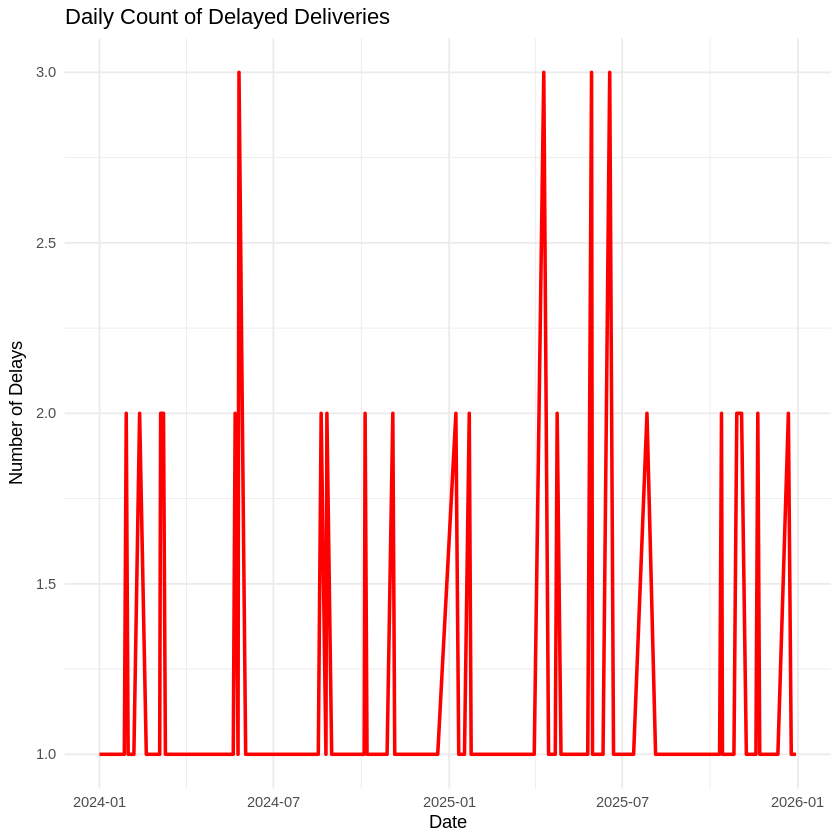

In [ ]:
library(ggplot2)
library(dplyr) # using dplyr to prepare some of the data for plotting

# 1. Line Chart: Delays over time
delay_timeline <- deliveries %>%
  filter(delivery_status == "Delayed") %>%
  mutate(date = as.Date(dispatch_time)) %>%
  group_by(date) %>%
  summarise(count = n())

ggplot(delay_timeline, aes(x = date, y = count)) +
  geom_line(color = "red", linewidth = 1) +
  labs(title = "Daily Count of Delayed Deliveries", x = "Date", y = "Number of Delays") +
  theme_minimal()

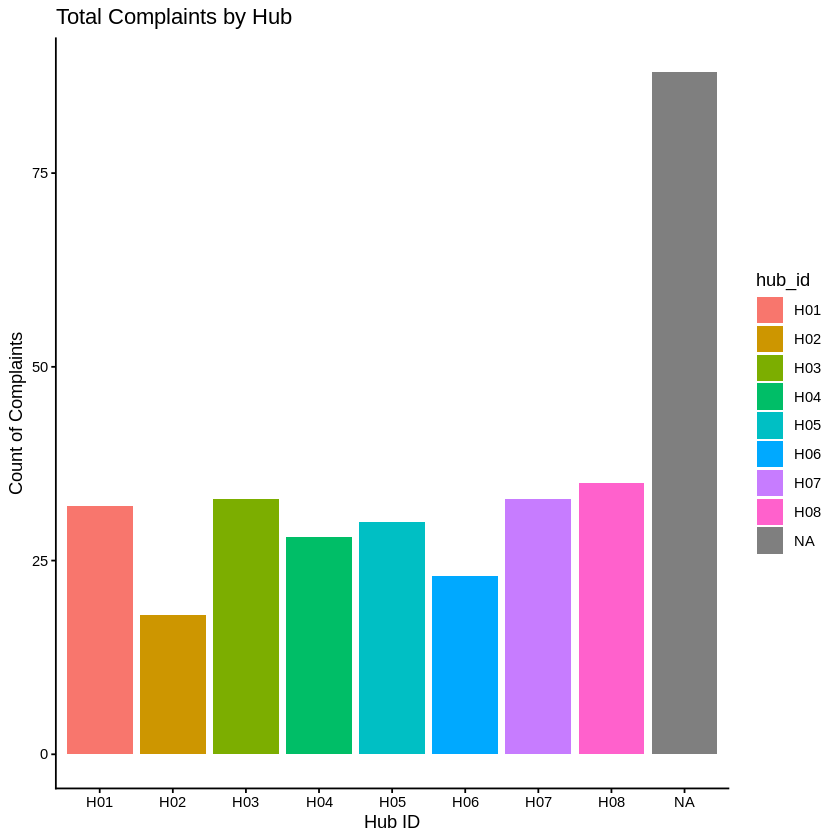

In [ ]:
# 2. Bar Chart: Complaints by Hub
# Complaints and hub are not connected so we need to join complaints with deliveries (using order_id) to get hub_id
complaints_hubs <- complaints %>%
  left_join(select(deliveries, order_id, hub_id), by = "order_id")

ggplot(complaints_hubs, aes(x = hub_id, fill = hub_id)) +
  geom_bar() +
  labs(title = "Total Complaints by Hub", x = "Hub ID", y = "Count of Complaints") +
  theme_classic()

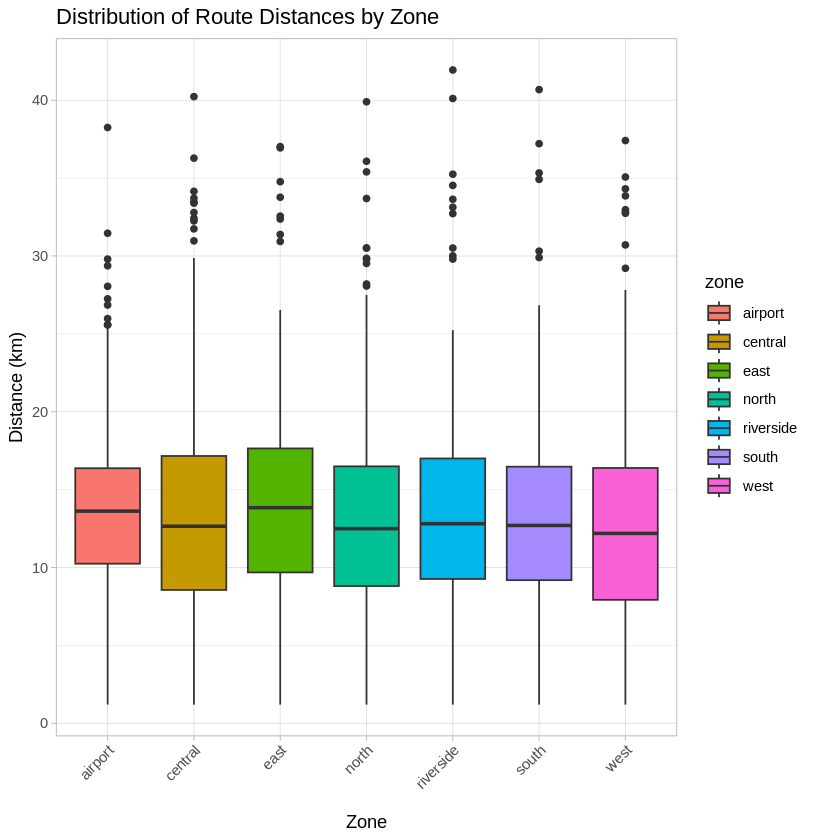

In [ ]:
# 3. Boxplot: Route Distance by Zone
# Using deliveries joined with hubs to get the zone column
deliveries_zones <- deliveries %>%
  left_join(select(hubs, hub_id, zone), by = "hub_id")

ggplot(deliveries_zones, aes(x = zone, y = route_distance_km, fill = zone)) +
  geom_boxplot() +
  labs(title = "Distribution of Route Distances by Zone", x = "Zone", y = "Distance (km)") +
  theme_light() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) #adjusting text on x axis to make it clearer

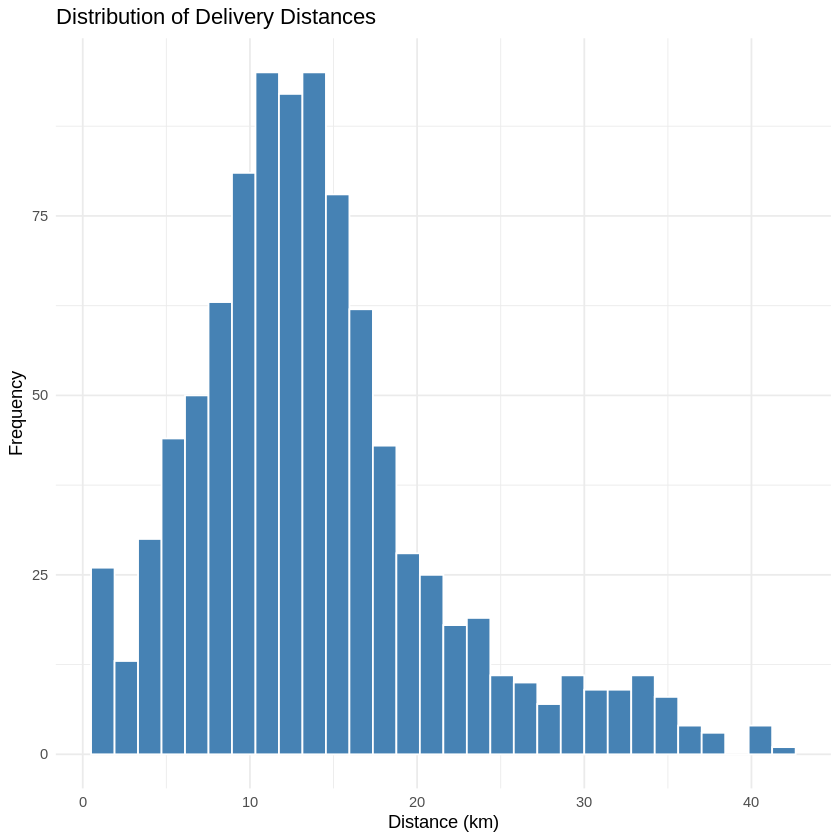

In [ ]:
# 4. Histogram: Distribution of Route Distances
# This shows how frequently different delivery distances occur
ggplot(deliveries, aes(x = route_distance_km)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Delivery Distances", x = "Distance (km)", y = "Frequency") +
  theme_minimal()

### Business Interpretation of Visualizations
1. **Line Chart (Daily Count of Delayed Deliveries)**: This graph helps identify whether delays are spiking on specific days of the week or during certain periods.
2. **Bar Chart (Total Complaints by Hub)**: With this graph we can figure out which hubs have the highest number of complaints. The management can then identify if specific locations have infrastructure issues, poor management, or high traffic congestion.
3. **Boxplot (Distribution of Route Distances by Zone)**: This gives insight into variance. If certain zones have higher median distances or significant 'outliers' (unusually long routes), it explains why drivers in those zones might be failing to meet delivery windows compared to more compact zones.
4. **Histogram (Distribution of Delivery Distances)**: This provides an overview of the service profile. It shows if the majority of deliveries have shorter or longer routes, which helps in optimizing the delivery procedure (e.g., deciding if more small electric vehicles or motorcycles are needed).

# Downloading Cleaned Data
Now that the dataframes have been cleaned, we can save them as new CSV files.

In [ ]:
for (name in names(tables)) {
  df <- get(name)
  # Construct a new filename, e.g., 'deliveries_cleaned.csv'
  filename <- paste0(name, "_cleaned.csv")
  write.csv(df, file = filename, row.names = FALSE)
  cat(paste0("Saved cleaned data to: ", filename, "\n"))
}

print("All cleaned dataframes have been saved to CSV files.")

Saved cleaned data to: deliveries_cleaned.csv
Saved cleaned data to: orders_cleaned.csv
Saved cleaned data to: complaints_cleaned.csv
Saved cleaned data to: app_events_cleaned.csv
Saved cleaned data to: customers_cleaned.csv
Saved cleaned data to: hubs_cleaned.csv
Saved cleaned data to: drivers_cleaned.csv
Saved cleaned data to: incidents_cleaned.csv
Saved cleaned data to: vehicles_cleaned.csv
[1] "All cleaned dataframes have been saved to CSV files."
